## Setup

In [1]:
import warnings
warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
    message=r".*force_all_finite.*" 
)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import adjusted_rand_score
from tslearn.clustering import TimeSeriesKMeans, silhouette_score
import ruptures as rpt

sns.set_theme(style="whitegrid")

/private/tmp/claude-501/-Users-korneliakozaczewska-Desktop-chmurka-git/149a1b5c-ee9c-4854-9cff-3207759881ef/scratchpad/housing-venv/lib/python3.12/site-packages/tslearn/bases/bases.py:16: UserWarning: h5py not installed, hdf5 features will not be supported.
Install h5py to use hdf5 features: http://docs.h5py.org/
  warn(h5py_msg)


## Data Loading

In [3]:
pierwotny_df = pd.read_excel("housing-prices-primary.xlsx", index_col=0, parse_dates=True)
pierwotny_df

/var/folders/tx/9g_s4rm56clg1s64hp55l8tw0000gn/T/ipykernel_30535/3737525399.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pierwotny_df = pd.read_excel("housing-prices-primary.xlsx", index_col=0, parse_dates=True)


,Białystok,Bydgoszcz,Gdańsk,Gdynia,Katowice,Kielce,Kraków,Lublin,Łódź,Olsztyn,Opole,Poznań,Rzeszów,Szczecin,Warszawa,Wrocław,Zielona Góra
Kwartał,,,,,,,,,,,,,,,,,
III 2006,3008.000000,2663.000000,3494.000000,4467.000000,3522.590000,2834.839339,6816.000000,3022.00,2860.000000,2640.000,3299.151723,3620.845241,2656.000000,3233.916487,5605.000000,3211.000000,2499.008930
IV 2006,3117.000000,2811.000000,5252.000000,5284.000000,3734.720000,3014.090525,7089.000000,3304.00,3642.000000,2869.000,3342.843092,4725.658134,3013.000000,3575.024357,6186.000000,3777.000000,2768.751404
I 2007,3500.000000,3017.000000,5490.000000,5797.000000,3805.670000,3241.415228,7192.000000,3309.00,4209.000000,2960.000,NaN,6444.721994,3469.000000,3831.400406,7302.000000,7062.859050,2499.814669
II 2007,4422.000000,4092.000000,7137.000000,6992.000000,5093.570000,3017.729302,7856.000000,3503.00,5403.000000,3318.000,3307.345458,7242.730000,3517.000000,4932.747279,7523.000000,5289.000000,3258.090803
III 2007,4651.000000,4466.000000,7440.000000,7238.000000,5697.620000,4765.978233,8060.000000,4125.00,5212.000000,3588.000,4253.276317,5425.817049,4124.000000,5121.045287,7879.000000,5835.806577,4015.413864
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
IV 2023,9383.859502,9122.395201,12355.046371,11108.754250,10347.839678,8208.391228,13481.661600,10085.05,9201.514367,8620.113,9487.954550,11059.945162,9426.315375,10553.396396,14926.628093,12498.112127,7655.291106
I 2024,9774.946167,9009.302049,12384.400061,11972.147547,10675.182052,8577.756452,14711.411628,9846.73,9755.252667,8837.202,10233.897368,11724.337309,9630.605907,11294.241219,15896.044088,12837.613692,7730.233832
II 2024,10129.065002,8940.238424,12561.785971,11800.278230,11508.088853,9446.269630,15461.819936,10771.97,10320.458054,9159.544,10428.235283,12437.802525,9514.392826,12199.262366,15986.919261,13536.565199,8299.172616


## Full Time Series

### Raw and Normalised Prices

In [4]:
pierwotny_slice_df = pierwotny_df.loc["I 2018":"IV 2024"]
pierwotny_slice_df

,Białystok,Bydgoszcz,Gdańsk,Gdynia,Katowice,Kielce,Kraków,Lublin,Łódź,Olsztyn,Opole,Poznań,Rzeszów,Szczecin,Warszawa,Wrocław,Zielona Góra
Kwartał,,,,,,,,,,,,,,,,,
I 2018,4944.000000,5635.000000,7254.886886,6851.479350,5217.348369,4591.489259,6795.534794,5473.0000,5211.000000,5363.686,4704.297237,6429.930362,4929.000000,5257.308212,7964.892386,6508.000000,3863.000000
II 2018,5052.000000,5403.000000,7543.476571,7080.415417,5464.118611,4797.976000,6778.373999,5479.0000,5206.000000,5239.704,4993.706427,6735.463439,5170.000000,5512.511210,8182.738187,6651.000000,3899.000000
III 2018,5351.000000,5393.000000,7256.830658,7417.874125,5486.889905,4804.822880,6944.889068,5545.0000,5356.000000,5311.443,5012.778437,6848.573656,5318.000000,5671.639186,8537.825168,6750.000000,3909.000000
IV 2018,5385.000000,5429.000000,7914.527126,7803.314461,5845.742319,4967.077231,7198.756150,5785.0000,5507.000000,5611.670,5312.083559,7016.985992,5227.000000,5880.256457,8564.578476,6905.000000,3994.000000
I 2019,5422.000000,5911.000000,8262.364454,7990.141022,6539.488814,4999.162510,7427.256629,5874.0000,5631.000000,5576.708,5302.899747,7055.721625,5117.000000,5960.421968,8771.154301,7032.000000,4243.000000
II 2019,5620.000000,5930.000000,8288.370137,8180.609053,6274.727063,5020.152215,7738.199268,5852.0000,5853.000000,5676.699,5222.317694,7086.543195,5523.000000,6494.744538,8932.049250,7435.000000,4496.000000
III 2019,5583.768923,6337.000000,8533.896551,8321.185776,6745.506032,5220.400743,7785.909332,6158.0000,5881.000000,5871.841,5728.367036,7101.569695,6105.000000,6649.788524,9188.448558,7661.000000,4539.000000
IV 2019,5687.500331,6190.000000,8585.225967,8027.319992,6879.938339,5295.153754,8235.060233,5977.4468,6026.000000,6107.897,5487.453865,7395.992746,5761.000000,6752.304090,9475.831959,7634.070064,4688.000000
I 2020,5838.748814,6331.000000,8741.374032,8251.159865,6996.087409,5424.637738,8306.973029,6158.1900,6249.000000,6219.963,6201.625898,7423.456194,6157.000000,6913.095419,9818.601940,8354.078189,4850.545709


In [5]:
pierwotny_slice_df.info()
pierwotny_slice_df.describe()

<class 'pandas.DataFrame'>
Index: 28 entries, I 2018 to IV 2024
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Białystok     28 non-null     float64
 1   Bydgoszcz     28 non-null     float64
 2   Gdańsk        28 non-null     float64
 3   Gdynia        28 non-null     float64
 4   Katowice      28 non-null     float64
 5   Kielce        28 non-null     float64
 6   Kraków        28 non-null     float64
 7   Lublin        28 non-null     float64
 8   Łódź          28 non-null     float64
 9   Olsztyn       28 non-null     float64
 10  Opole         28 non-null     float64
 11  Poznań        28 non-null     float64
 12  Rzeszów       28 non-null     float64
 13  Szczecin      28 non-null     float64
 14  Warszawa      28 non-null     float64
 15  Wrocław       28 non-null     float64
 16  Zielona Góra  28 non-null     float64
dtypes: float64(17)
memory usage: 3.9+ KB


,Białystok,Bydgoszcz,Gdańsk,Gdynia,Katowice,Kielce,Kraków,Lublin,Łódź,Olsztyn,Opole,Poznań,Rzeszów,Szczecin,Warszawa,Wrocław,Zielona Góra
count,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000
mean,7205.915770,7278.390289,10075.955369,9486.055275,8226.727187,6762.511513,10273.690975,7703.913457,7359.032814,7047.950321,7143.133422,8804.898724,7112.174591,8561.299617,11546.294866,9571.835200,6066.514309
std,1794.127813,1300.898161,1776.919089,1612.041156,1979.786307,1683.225041,2815.619365,1840.849487,1625.261686,1306.375297,1911.665906,1902.311553,1649.998117,2272.886784,2668.428501,2412.095917,1601.901122
min,4944.000000,5393.000000,7254.886886,6851.479350,5217.348369,4591.489259,6778.373999,5473.000000,5206.000000,5239.704000,4704.297237,6429.930362,4929.000000,5257.308212,7964.892386,6508.000000,3863.000000
25%,5670.625248,6295.750000,8572.393613,8106.459019,6808.248520,5276.465502,8122.772508,5977.050100,5989.750000,6048.883000,5668.138744,7322.386983,5823.820000,6711.565917,9375.797039,7654.267516,4650.750000
50%,6542.068960,7112.626015,10151.493749,9781.641025,8064.676237,6413.672901,9552.118598,7203.600000,7063.104589,6808.817000,6216.469582,7993.059410,6603.590000,8216.742949,10850.690784,8734.293010,5865.513711
75%,8481.186918,8378.075090,11539.397868,10833.037284,9611.138795,8226.843847,11731.675532,9151.285000,8573.042971,8096.551750,8776.069529,10016.973690,8330.949008,10716.857723,12921.899433,11182.981084,7496.171342
max,10444.432335,9590.465912,13023.125279,12265.657196,11931.322536,10287.600970,16041.975508,10967.010000,10320.458054,9484.960000,10584.451098,12789.879301,10718.435272,12199.262366,16584.125048,14724.575050,8734.791416


In [6]:
pierwotny_slice_df_n = pierwotny_slice_df.div(pierwotny_slice_df.loc["I 2018"]).fillna(1)
pierwotny_slice_df_n 

,Białystok,Bydgoszcz,Gdańsk,Gdynia,Katowice,Kielce,Kraków,Lublin,Łódź,Olsztyn,Opole,Poznań,Rzeszów,Szczecin,Warszawa,Wrocław,Zielona Góra
Kwartał,,,,,,,,,,,,,,,,,
I 2018,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
II 2018,1.021845,0.958829,1.039779,1.033414,1.047298,1.044972,0.997475,1.001096,0.999040,0.976885,1.061520,1.047517,1.048894,1.048543,1.027351,1.021973,1.009319
III 2018,1.082322,0.957054,1.000268,1.082668,1.051663,1.046463,1.021978,1.013155,1.027826,0.990260,1.065574,1.065109,1.078921,1.078810,1.071932,1.037185,1.011908
IV 2018,1.089199,0.963443,1.090924,1.138924,1.120443,1.081801,1.059336,1.057007,1.056803,1.046234,1.129198,1.091300,1.060459,1.118492,1.075291,1.061002,1.033911
I 2019,1.096683,1.048980,1.138869,1.166192,1.253412,1.088789,1.092961,1.073269,1.080599,1.039716,1.127246,1.097325,1.038142,1.133740,1.101227,1.080516,1.098369
II 2019,1.136731,1.052351,1.142453,1.193992,1.202666,1.093360,1.138718,1.069249,1.123201,1.058358,1.110116,1.102118,1.120511,1.235375,1.121427,1.142440,1.163862
III 2019,1.129403,1.124579,1.176296,1.214509,1.292899,1.136973,1.145739,1.125160,1.128574,1.094740,1.217688,1.104455,1.238588,1.264866,1.153619,1.177167,1.174994
IV 2019,1.150384,1.098492,1.183371,1.171619,1.318666,1.153254,1.211834,1.092170,1.156400,1.138750,1.166477,1.150245,1.168797,1.284365,1.189700,1.173029,1.213565
I 2020,1.180977,1.123514,1.204895,1.204289,1.340928,1.181455,1.222416,1.125195,1.199194,1.159643,1.318290,1.154516,1.249138,1.314950,1.232735,1.283663,1.255642


### Visualisations

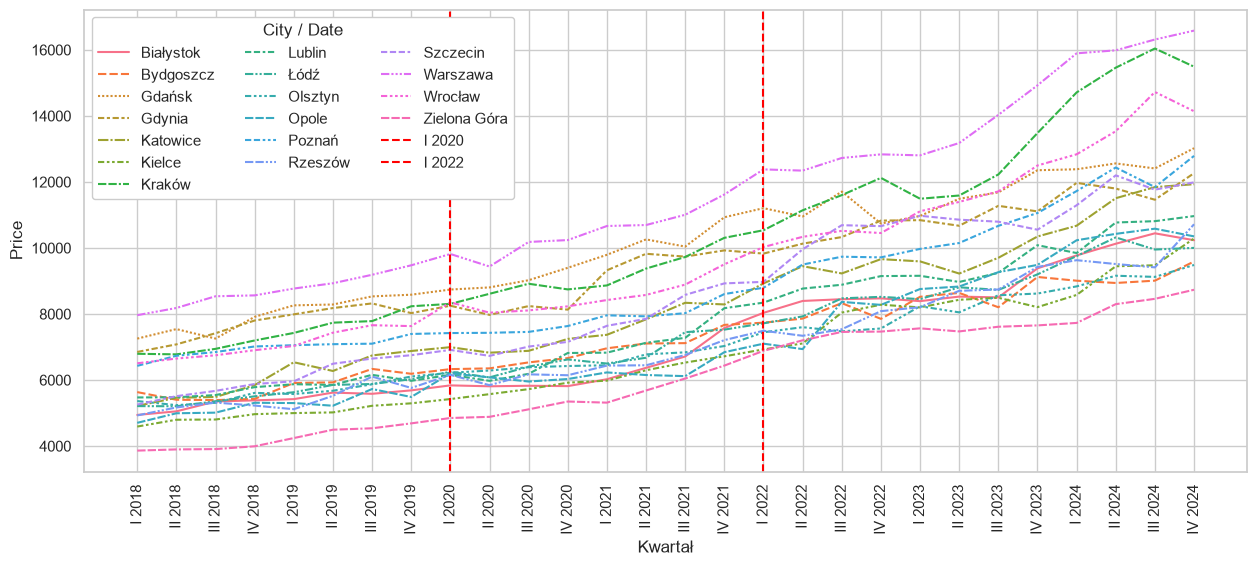

In [7]:
plt.figure(figsize=(15, 6))
sns.lineplot(data=pierwotny_slice_df)

x_pos_2020 = pierwotny_slice_df.index.get_loc("I 2020")
plt.axvline(x=x_pos_2020, color='red', linestyle='--', label="I 2020")
x_pos_2020 = pierwotny_slice_df.index.get_loc("I 2022")
plt.axvline(x=x_pos_2020, color='red', linestyle='--', label="I 2022")

legend = plt.legend(title="City / Date", ncol=3, loc='upper left')
frame = legend.get_frame()
frame.set_alpha(1) 

plt.xticks(rotation=90)
plt.ylabel("Price")
plt.show()

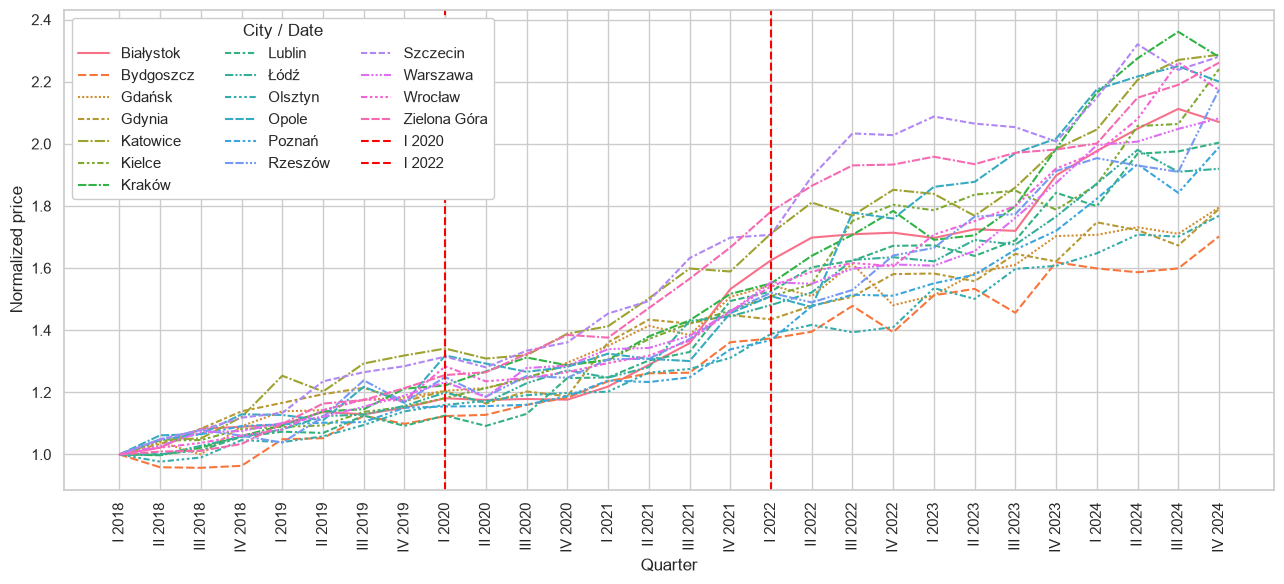

In [8]:
plt.figure(figsize=(13, 6))
sns.lineplot(data=pierwotny_slice_df_n)

plt.legend(title="City", ncol=2, loc='upper left')
plt.xlabel("Quarter")
plt.ylabel("Normalized price")
plt.xticks(rotation=90)

x_pos_2020 = pierwotny_slice_df_n.index.get_loc("I 2020")
plt.axvline(x=x_pos_2020, color='red', linestyle='--', label="I 2020")
x_pos_2020 = pierwotny_slice_df_n.index.get_loc("I 2022")
plt.axvline(x=x_pos_2020, color='red', linestyle='--', label="I 2022")

legend = plt.legend(title="City / Date", ncol=3, loc='upper left')
frame = legend.get_frame()
frame.set_alpha(1) 

plt.tight_layout()
plt.show()


### Cluster Count Selection (Silhouette Score)

k = 2    silhouette = 0.4285


k = 3    silhouette = 0.3661


k = 4    silhouette = 0.3622


k = 5    silhouette = 0.3318


k = 6    silhouette = 0.2343


k = 7    silhouette = 0.2622


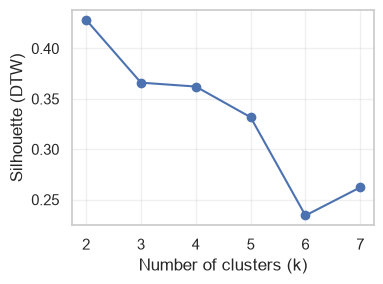


Optimal number of clusters by silhouette: k = 2


In [9]:
X = np.stack([pierwotny_slice_df_n[c].values
              for c in pierwotny_slice_df_n.columns])[..., None]


metric_kw = {"sakoe_chiba_radius": 1}


k_range      = range(2, 8)
random_state = 42
sils         = []

for k in k_range:
    labels = TimeSeriesKMeans(n_clusters=k,
                              metric="dtw",
                              metric_params=metric_kw,
                              random_state=random_state,
                              max_iter=300,
                              n_jobs=-1).fit_predict(X)

    s = silhouette_score(X, labels, metric="dtw", metric_params=metric_kw)
    sils.append(s)
    print(f"k = {k:<2d}   silhouette = {s:.4f}")


plt.figure(figsize=(4,3))
plt.plot(list(k_range), sils, "o-")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette (DTW)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


best_k = k_range[int(np.argmax(sils))]
print(f"\nOptimal number of clusters by silhouette: k = {best_k}")


### Cluster Stability

In [10]:
X = np.stack([pierwotny_slice_df_n[c].values
              for c in pierwotny_slice_df_n.columns])[..., None]

metric_kw = {"sakoe_chiba_radius": 1}

rng       = np.random.default_rng(0)
k_range   = range(2, 8)            # e.g. 2-7 clusters
n_boot    = 200
keep      = 0.8

results = []

for k in k_range:
    labels_full = TimeSeriesKMeans(k, metric="dtw",
                                   metric_params=metric_kw,
                                   random_state=42).fit_predict(X)
    
    sil_b, ari_b = [], []
    
    for _ in range(n_boot):
        mask = rng.random(len(X)) < keep
        if mask.sum() <= k:
            continue
        
        lbl = TimeSeriesKMeans(k, metric="dtw",
                               metric_params=metric_kw,
                               random_state=rng.integers(1e6)
                              ).fit_predict(X[mask])
        
        sil_b.append(silhouette_score(X[mask], lbl,
                                      metric="dtw", metric_params=metric_kw))
        ari_b.append(adjusted_rand_score(labels_full[mask], lbl))
    
    results.append({
        "k": k,
        "S_mean": np.mean(sil_b),
        "S_sd":   np.std(sil_b),
        "ARI":    np.mean(ari_b)
    })


df_res = pd.DataFrame(results)
display(df_res)


,k,S_mean,S_sd,ARI
0,2,0.443795,0.042756,0.611471
1,3,0.376491,0.049834,0.546235
2,4,0.318749,0.055855,0.518019
3,5,0.256491,0.065576,0.516646
4,6,0.221847,0.059946,0.401013
5,7,0.176179,0.061613,0.506979


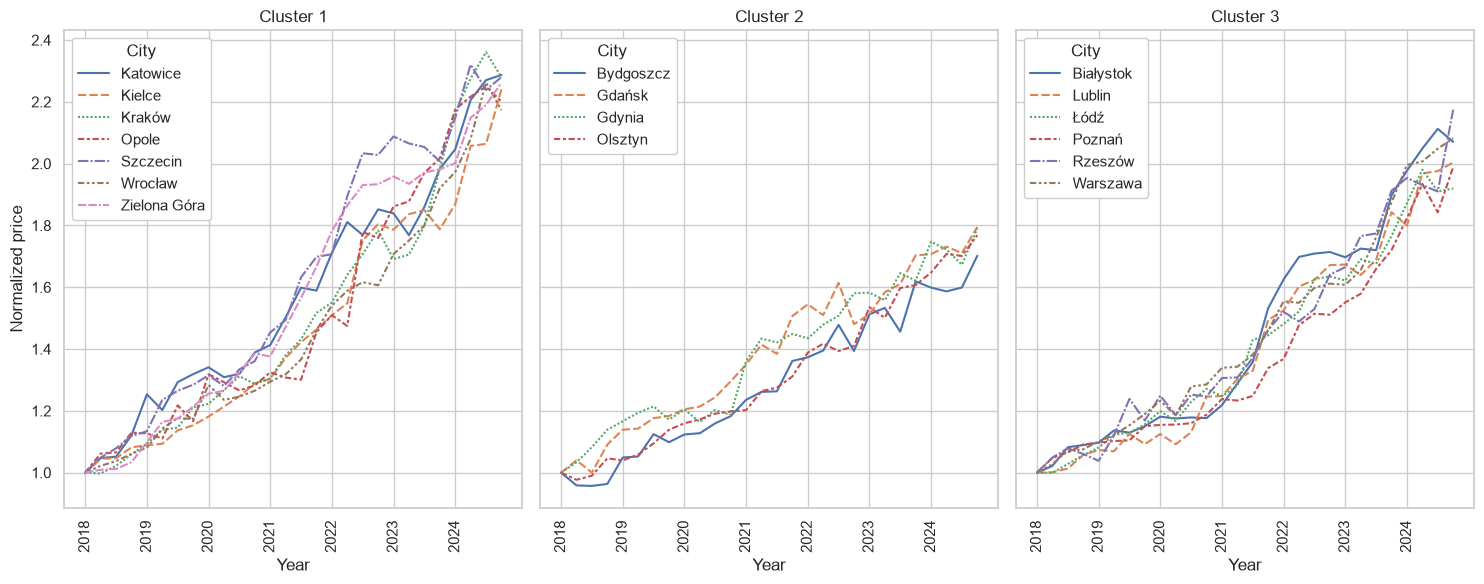

In [11]:
X = np.array([pierwotny_slice_df_n[city].values for city in pierwotny_slice_df_n.columns])

model1 = TimeSeriesKMeans(n_clusters=3, metric="dtw", max_iter=300, random_state=42)
labels1 = model1.fit_predict(X)

years = sorted({int(label.split()[1]) for label in pierwotny_slice_df_n.index})
positions = [pierwotny_slice_df_n.index.get_loc(f"I {year}") for year in years]
labels    = [str(year) for year in years]

fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharey=True)
for cluster in range(3):
    cluster_cities = [
        pierwotny_slice_df_n.columns[i]
        for i,lab in enumerate(labels1)  # zakładam labels1 z Twojej klasteryzacji
        if lab == cluster
    ]
    sns.lineplot(data=pierwotny_slice_df_n[cluster_cities],
                 ax=axes[cluster])
    axes[cluster].set_title(f"Cluster {cluster+1}")
    axes[cluster].set_xticks(positions)
    axes[cluster].set_xticklabels(labels, rotation=90)
    axes[cluster].set_xlabel("Year")
    if cluster == 0:
        axes[cluster].set_ylabel("Normalized price")
    else:
        axes[cluster].set_ylabel("")
    leg = axes[cluster].legend(title="City", loc="upper left")
    leg.get_frame().set_facecolor("white")
    leg.get_frame().set_alpha(1)

plt.tight_layout()
plt.show()


## Period I - Pre-COVID (2018-2020)

### Normalised Prices

In [12]:
pierwotny_slice_poczatek_covid_df_n = pierwotny_slice_df_n.loc[:"I 2020"]
pierwotny_slice_poczatek_covid_df_n.info()
pierwotny_slice_poczatek_covid_df_n

<class 'pandas.DataFrame'>
Index: 9 entries, I 2018 to I 2020
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Białystok     9 non-null      float64
 1   Bydgoszcz     9 non-null      float64
 2   Gdańsk        9 non-null      float64
 3   Gdynia        9 non-null      float64
 4   Katowice      9 non-null      float64
 5   Kielce        9 non-null      float64
 6   Kraków        9 non-null      float64
 7   Lublin        9 non-null      float64
 8   Łódź          9 non-null      float64
 9   Olsztyn       9 non-null      float64
 10  Opole         9 non-null      float64
 11  Poznań        9 non-null      float64
 12  Rzeszów       9 non-null      float64
 13  Szczecin      9 non-null      float64
 14  Warszawa      9 non-null      float64
 15  Wrocław       9 non-null      float64
 16  Zielona Góra  9 non-null      float64
dtypes: float64(17)
memory usage: 1.3+ KB


,Białystok,Bydgoszcz,Gdańsk,Gdynia,Katowice,Kielce,Kraków,Lublin,Łódź,Olsztyn,Opole,Poznań,Rzeszów,Szczecin,Warszawa,Wrocław,Zielona Góra
Kwartał,,,,,,,,,,,,,,,,,
I 2018,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
II 2018,1.021845,0.958829,1.039779,1.033414,1.047298,1.044972,0.997475,1.001096,0.999040,0.976885,1.061520,1.047517,1.048894,1.048543,1.027351,1.021973,1.009319
III 2018,1.082322,0.957054,1.000268,1.082668,1.051663,1.046463,1.021978,1.013155,1.027826,0.990260,1.065574,1.065109,1.078921,1.078810,1.071932,1.037185,1.011908
IV 2018,1.089199,0.963443,1.090924,1.138924,1.120443,1.081801,1.059336,1.057007,1.056803,1.046234,1.129198,1.091300,1.060459,1.118492,1.075291,1.061002,1.033911
I 2019,1.096683,1.048980,1.138869,1.166192,1.253412,1.088789,1.092961,1.073269,1.080599,1.039716,1.127246,1.097325,1.038142,1.133740,1.101227,1.080516,1.098369
II 2019,1.136731,1.052351,1.142453,1.193992,1.202666,1.093360,1.138718,1.069249,1.123201,1.058358,1.110116,1.102118,1.120511,1.235375,1.121427,1.142440,1.163862
III 2019,1.129403,1.124579,1.176296,1.214509,1.292899,1.136973,1.145739,1.125160,1.128574,1.094740,1.217688,1.104455,1.238588,1.264866,1.153619,1.177167,1.174994
IV 2019,1.150384,1.098492,1.183371,1.171619,1.318666,1.153254,1.211834,1.092170,1.156400,1.138750,1.166477,1.150245,1.168797,1.284365,1.189700,1.173029,1.213565
I 2020,1.180977,1.123514,1.204895,1.204289,1.340928,1.181455,1.222416,1.125195,1.199194,1.159643,1.318290,1.154516,1.249138,1.314950,1.232735,1.283663,1.255642


### Cluster Count Selection (Silhouette Score)

k = 2    silhouette = 0.3518


k = 3    silhouette = 0.3456


k = 4    silhouette = 0.3035


k = 5    silhouette = 0.2571


k = 6    silhouette = 0.2065


k = 7    silhouette = 0.1382


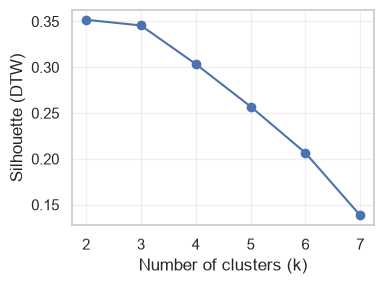


Optimal number of clusters by silhouette: k = 2


In [13]:
X = np.stack([pierwotny_slice_poczatek_covid_df_n[c].values
              for c in pierwotny_slice_poczatek_covid_df_n.columns])[..., None]

metric_kw = {"sakoe_chiba_radius": 1}

k_range      = range(2, 8)
random_state = 42
sils1         = []

for k in k_range:
    labels = TimeSeriesKMeans(n_clusters=k,
                              metric="dtw",
                              metric_params=metric_kw,
                              random_state=random_state,
                              max_iter=300,
                              n_jobs=-1).fit_predict(X)

    s = silhouette_score(X, labels, metric="dtw", metric_params=metric_kw)
    sils1.append(s)
    print(f"k = {k:<2d}   silhouette = {s:.4f}")


plt.figure(figsize=(4,3))
plt.plot(list(k_range), sils1, "o-")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette (DTW)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


best_k = k_range[int(np.argmax(sils1))]
print(f"\nOptimal number of clusters by silhouette: k = {best_k}")


### Cluster Stability

In [14]:
X = np.stack([pierwotny_slice_poczatek_covid_df_n[c].values
              for c in pierwotny_slice_poczatek_covid_df_n.columns])[..., None]

metric_kw = {"sakoe_chiba_radius": 1}

rng       = np.random.default_rng(0)
k_range   = range(2, 8)            # e.g. 2-7 clusters
n_boot    = 200
keep      = 0.8

results = []

for k in k_range:
    labels_full = TimeSeriesKMeans(k, metric="dtw",
                                   metric_params=metric_kw,
                                   random_state=42).fit_predict(X)
    
    sil_b, ari_b = [], []
    
    for _ in range(n_boot):
        mask = rng.random(len(X)) < keep
        if mask.sum() <= k:
            continue
        
        lbl = TimeSeriesKMeans(k, metric="dtw",
                               metric_params=metric_kw,
                               random_state=rng.integers(1e6)
                              ).fit_predict(X[mask])
        
        sil_b.append(silhouette_score(X[mask], lbl,
                                      metric="dtw", metric_params=metric_kw))
        ari_b.append(adjusted_rand_score(labels_full[mask], lbl))
    
    results.append({
        "k": k,
        "S_mean": np.mean(sil_b),
        "S_sd":   np.std(sil_b),
        "ARI":    np.mean(ari_b)
    })


df_res = pd.DataFrame(results)
display(df_res)

,k,S_mean,S_sd,ARI
0,2,0.400872,0.104911,0.400742
1,3,0.332332,0.071561,0.456640
2,4,0.270238,0.061424,0.376452
3,5,0.243704,0.060079,0.433026
4,6,0.226104,0.062616,0.396300
5,7,0.190260,0.060978,0.338460


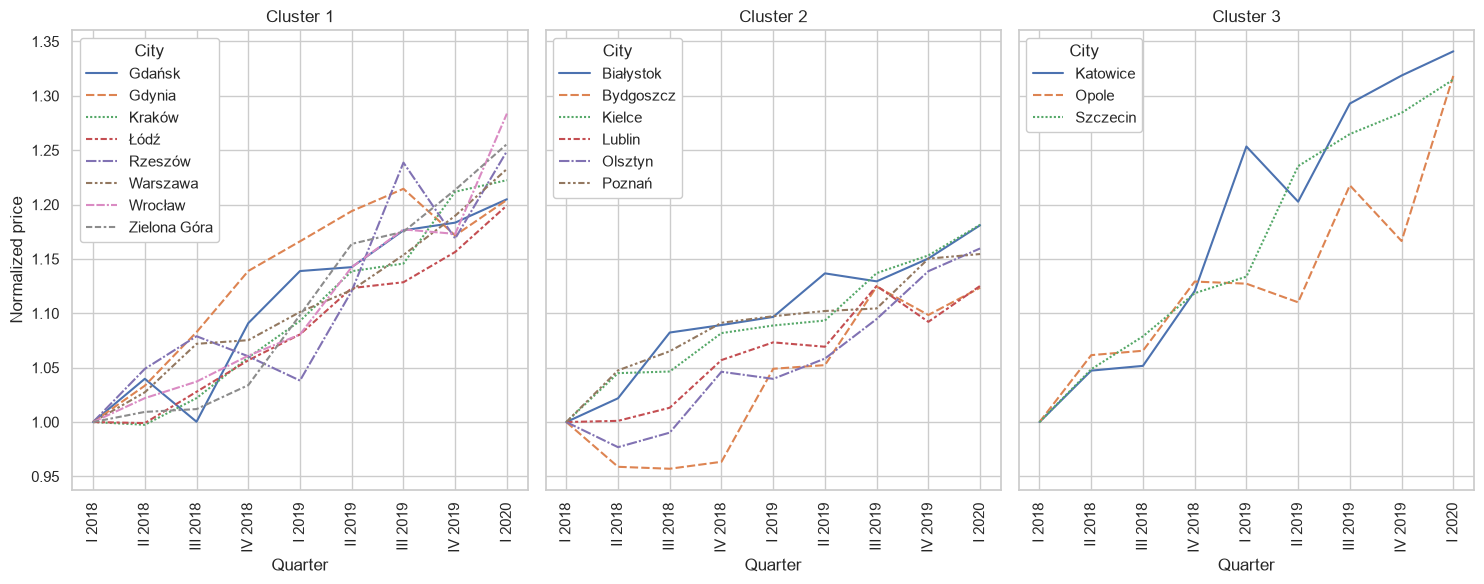

In [15]:
model2 = TimeSeriesKMeans(n_clusters=3, metric="dtw", max_iter=300, random_state=42)
labels2 = model2.fit_predict(X)


fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharey=True)

for cluster in range(3):
    cluster_cities = [pierwotny_slice_poczatek_covid_df_n.columns[i] for i in range(len(labels2)) if labels2[i] == cluster]
    
    sns.lineplot(data=pierwotny_slice_poczatek_covid_df_n[cluster_cities], ax=axes[cluster])
    
    axes[cluster].set_title(f'Cluster {cluster + 1}')
    axes[cluster].set_xlabel("Quarter")
    axes[cluster].set_ylabel("Normalized price")
    axes[cluster].tick_params(axis='x', rotation=90)

    leg = axes[cluster].legend(title="City", loc='upper left')
    leg.get_frame().set_facecolor('white')
    leg.get_frame().set_alpha(1)
    

plt.tight_layout()
plt.show()

## Period II - COVID to War (2020-2022)

### Normalised Prices

In [16]:
pierwotny_slice_covid_wojna_df_n = pierwotny_slice_df_n.loc["II 2020":"I 2022"]
pierwotny_slice_covid_wojna_df_n.info()
pierwotny_slice_covid_wojna_df_n

<class 'pandas.DataFrame'>
Index: 8 entries, II 2020 to I 2022
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Białystok     8 non-null      float64
 1   Bydgoszcz     8 non-null      float64
 2   Gdańsk        8 non-null      float64
 3   Gdynia        8 non-null      float64
 4   Katowice      8 non-null      float64
 5   Kielce        8 non-null      float64
 6   Kraków        8 non-null      float64
 7   Lublin        8 non-null      float64
 8   Łódź          8 non-null      float64
 9   Olsztyn       8 non-null      float64
 10  Opole         8 non-null      float64
 11  Poznań        8 non-null      float64
 12  Rzeszów       8 non-null      float64
 13  Szczecin      8 non-null      float64
 14  Warszawa      8 non-null      float64
 15  Wrocław       8 non-null      float64
 16  Zielona Góra  8 non-null      float64
dtypes: float64(17)
memory usage: 1.1+ KB


,Białystok,Bydgoszcz,Gdańsk,Gdynia,Katowice,Kielce,Kraków,Lublin,Łódź,Olsztyn,Opole,Poznań,Rzeszów,Szczecin,Warszawa,Wrocław,Zielona Góra
Kwartał,,,,,,,,,,,,,,,,,
II 2020,1.175357,1.127595,1.213809,1.163887,1.308934,1.213781,1.267389,1.091880,1.166812,1.172538,1.292759,1.155678,1.185790,1.280533,1.184981,1.235494,1.264717
III 2020,1.178650,1.159716,1.243898,1.202729,1.319613,1.246861,1.312149,1.130716,1.229385,1.190916,1.265953,1.159996,1.252396,1.334192,1.278455,1.246005,1.323565
IV 2020,1.176402,1.182765,1.295703,1.187019,1.388833,1.289427,1.286940,1.246055,1.271200,1.197879,1.282109,1.187629,1.246825,1.361067,1.285603,1.265029,1.384937
I 2021,1.218548,1.235570,1.349962,1.361003,1.412816,1.302858,1.304689,1.247879,1.247442,1.202193,1.324600,1.238054,1.306070,1.453740,1.339110,1.294319,1.376118
II 2021,1.288501,1.261235,1.414216,1.433909,1.502471,1.371514,1.379872,1.302527,1.281042,1.263645,1.307839,1.233233,1.308125,1.493830,1.342833,1.318008,1.471351
III 2021,1.357967,1.263210,1.384309,1.421428,1.598566,1.422208,1.431420,1.329887,1.429803,1.275212,1.300699,1.248150,1.371359,1.632006,1.381797,1.366163,1.565415
IV 2021,1.532334,1.361352,1.506638,1.448932,1.589013,1.463242,1.516847,1.494040,1.444555,1.310853,1.454875,1.338278,1.462788,1.698142,1.458898,1.460796,1.666568
I 2022,1.625321,1.373216,1.544648,1.434762,1.711222,1.509045,1.550647,1.524749,1.481080,1.388194,1.509604,1.367898,1.520226,1.706978,1.554404,1.541071,1.782284


### Cluster Count Selection (Silhouette Score)

k = 2    silhouette = 0.3111


k = 3    silhouette = 0.5230


k = 4    silhouette = 0.3412


k = 5    silhouette = 0.3303


k = 6    silhouette = 0.2439


k = 7    silhouette = 0.2446


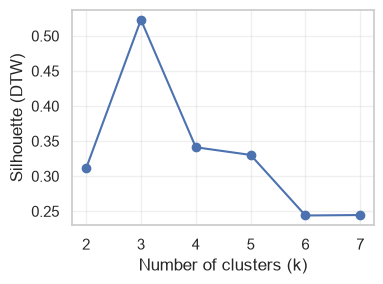


Optimal number of clusters by silhouette: k = 3


In [17]:
X = np.stack([pierwotny_slice_covid_wojna_df_n[c].values
              for c in pierwotny_slice_covid_wojna_df_n.columns])[..., None]


metric_kw = {"sakoe_chiba_radius": 1}


k_range      = range(2, 8)
random_state = 42
sils2         = []

for k in k_range:
    labels = TimeSeriesKMeans(n_clusters=k,
                              metric="dtw",
                              metric_params=metric_kw,
                              random_state=random_state,
                              max_iter=300,
                              n_jobs=-1).fit_predict(X)

    s = silhouette_score(X, labels, metric="dtw", metric_params=metric_kw)
    sils2.append(s)
    print(f"k = {k:<2d}   silhouette = {s:.4f}")


plt.figure(figsize=(4,3))
plt.plot(list(k_range), sils2, "o-")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette (DTW)")
#plt.title("Silhouette score, Period II")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


best_k = k_range[int(np.argmax(sils2))]
print(f"\nOptimal number of clusters by silhouette: k = {best_k}")


### Cluster Stability

In [18]:
X = np.stack([pierwotny_slice_covid_wojna_df_n[c].values
              for c in pierwotny_slice_covid_wojna_df_n.columns])[..., None]

metric_kw = {"sakoe_chiba_radius": 1}

rng       = np.random.default_rng(0)
k_range   = range(2, 8)            # e.g. 2-7 clusters
n_boot    = 200
keep      = 0.8

results = []

for k in k_range:
    labels_full = TimeSeriesKMeans(k, metric="dtw",
                                   metric_params=metric_kw,
                                   random_state=42).fit_predict(X)
    
    sil_b, ari_b = [], []
    
    for _ in range(n_boot):
        mask = rng.random(len(X)) < keep
        if mask.sum() <= k:
            continue
        
        lbl = TimeSeriesKMeans(k, metric="dtw",
                               metric_params=metric_kw,
                               random_state=rng.integers(1e6)
                              ).fit_predict(X[mask])
        
        sil_b.append(silhouette_score(X[mask], lbl,
                                      metric="dtw", metric_params=metric_kw))
        ari_b.append(adjusted_rand_score(labels_full[mask], lbl))
    
    results.append({
        "k": k,
        "S_mean": np.mean(sil_b),
        "S_sd":   np.std(sil_b),
        "ARI":    np.mean(ari_b)
    })


df_res = pd.DataFrame(results)
display(df_res)

,k,S_mean,S_sd,ARI
0,2,0.494949,0.127647,0.117029
1,3,0.440879,0.117239,0.773415
2,4,0.389690,0.080186,0.552931
3,5,0.353884,0.081317,0.535827
4,6,0.301640,0.082111,0.484972
5,7,0.252117,0.077487,0.577695


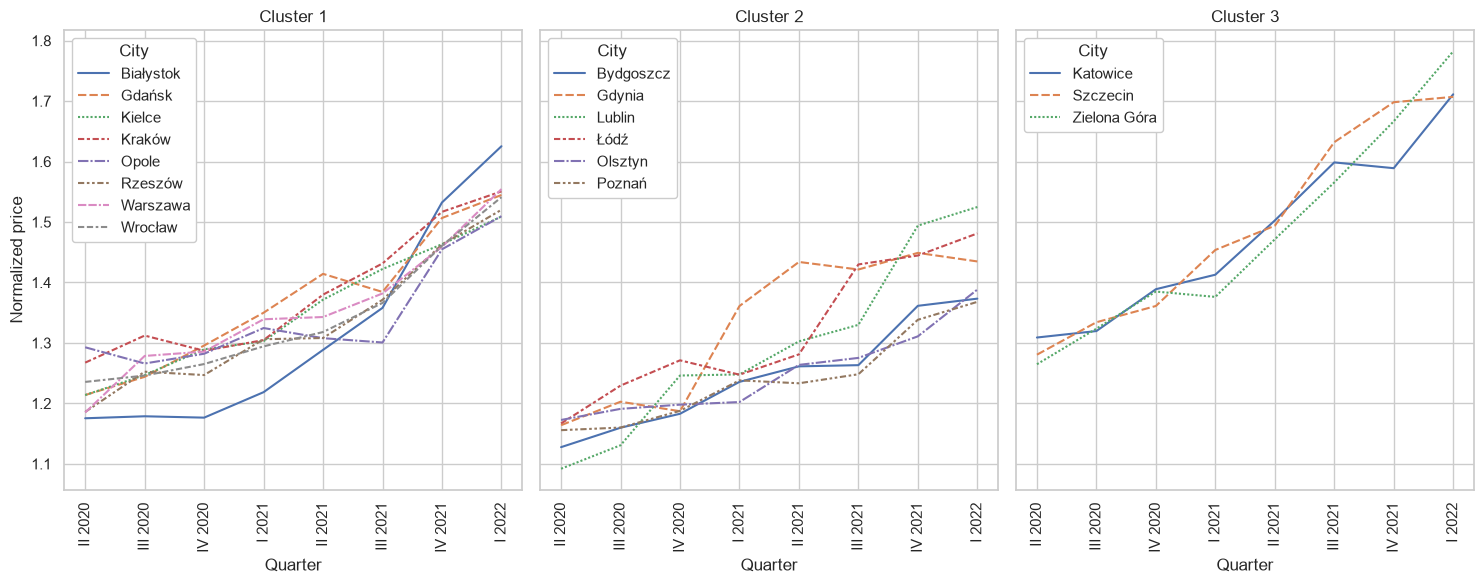

In [19]:
model3 = TimeSeriesKMeans(n_clusters=3, metric="dtw", max_iter=300, random_state=42)
labels3 = model3.fit_predict(X)


fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharey=True)

for cluster in range(3):
    cluster_cities = [pierwotny_slice_covid_wojna_df_n.columns[i] for i in range(len(labels3)) if labels3[i] == cluster]
    
    sns.lineplot(data=pierwotny_slice_covid_wojna_df_n[cluster_cities], ax=axes[cluster])
    
    axes[cluster].set_title(f'Cluster {cluster + 1}')
    axes[cluster].set_xlabel("Quarter")
    axes[cluster].set_ylabel("Normalized price")
    axes[cluster].tick_params(axis='x', rotation=90)

    leg = axes[cluster].legend(title="City", loc='upper left')
    leg.get_frame().set_facecolor('white')
    leg.get_frame().set_alpha(1)
    

plt.tight_layout()
plt.show()

## Period III - War and Aftermath (2022-2024)

### Normalised Prices

In [20]:
pierwotny_slice_wojna_koniec_df_n = pierwotny_slice_df_n.loc["II 2022":]
pierwotny_slice_wojna_koniec_df_n.info()
pierwotny_slice_wojna_koniec_df_n

<class 'pandas.DataFrame'>
Index: 11 entries, II 2022 to IV 2024
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Białystok     11 non-null     float64
 1   Bydgoszcz     11 non-null     float64
 2   Gdańsk        11 non-null     float64
 3   Gdynia        11 non-null     float64
 4   Katowice      11 non-null     float64
 5   Kielce        11 non-null     float64
 6   Kraków        11 non-null     float64
 7   Lublin        11 non-null     float64
 8   Łódź          11 non-null     float64
 9   Olsztyn       11 non-null     float64
 10  Opole         11 non-null     float64
 11  Poznań        11 non-null     float64
 12  Rzeszów       11 non-null     float64
 13  Szczecin      11 non-null     float64
 14  Warszawa      11 non-null     float64
 15  Wrocław       11 non-null     float64
 16  Zielona Góra  11 non-null     float64
dtypes: float64(17)
memory usage: 1.5+ KB


,Białystok,Bydgoszcz,Gdańsk,Gdynia,Katowice,Kielce,Kraków,Lublin,Łódź,Olsztyn,Opole,Poznań,Rzeszów,Szczecin,Warszawa,Wrocław,Zielona Góra
Kwartał,,,,,,,,,,,,,,,,,
II 2022,1.698186,1.395177,1.509904,1.478675,1.811019,1.548173,1.639554,1.602542,1.521580,1.417263,1.474707,1.477180,1.489340,1.894640,1.549727,1.588450,1.864717
III 2022,1.708889,1.478270,1.613686,1.507795,1.768933,1.751801,1.707174,1.623678,1.626407,1.393393,1.778654,1.514167,1.529623,2.033408,1.597827,1.616398,1.930538
IV 2022,1.713958,1.393663,1.480492,1.580643,1.852005,1.803816,1.783998,1.671668,1.635062,1.409992,1.759430,1.511045,1.640636,2.028041,1.611567,1.606220,1.933289
I 2023,1.696955,1.512359,1.512146,1.582565,1.838865,1.786067,1.691041,1.673309,1.621724,1.535465,1.861513,1.550922,1.665047,2.087820,1.607821,1.707404,1.958495
II 2023,1.724908,1.533185,1.583891,1.557773,1.768322,1.836427,1.705463,1.639141,1.690608,1.500862,1.877633,1.578700,1.765621,2.065195,1.654728,1.751162,1.934508
III 2023,1.719927,1.456110,1.610603,1.645891,1.859669,1.849474,1.799256,1.689512,1.675540,1.597388,1.970026,1.659460,1.773728,2.053652,1.761759,1.799835,1.971230
IV 2023,1.898030,1.618881,1.702996,1.621366,1.983352,1.787740,1.983900,1.842691,1.765787,1.607125,2.016870,1.720072,1.912419,2.007376,1.874053,1.920423,1.981696
I 2024,1.977133,1.598811,1.707042,1.747381,2.046093,1.868186,2.164864,1.799147,1.872050,1.647599,2.175436,1.823400,1.953866,2.148294,1.995764,1.972590,2.001096
II 2024,2.048759,1.586555,1.731493,1.722296,2.205735,2.057343,2.275291,1.968202,1.980514,1.707696,2.216747,1.934360,1.930289,2.320439,2.007173,2.079989,2.148375


### Cluster Count Selection (Silhouette Score)

k = 2    silhouette = 0.4621


k = 3    silhouette = 0.4014


k = 4    silhouette = 0.2730


k = 5    silhouette = 0.3128


k = 6    silhouette = 0.2251


k = 7    silhouette = 0.1556


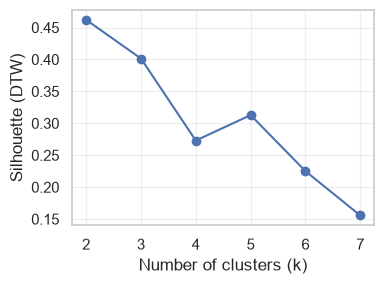


Optimal number of clusters by silhouette: k = 2


In [21]:
X = np.stack([pierwotny_slice_wojna_koniec_df_n[c].values
              for c in pierwotny_slice_wojna_koniec_df_n.columns])[..., None]


metric_kw = {"sakoe_chiba_radius": 1}


k_range      = range(2, 8)
random_state = 42
sils3         = []

for k in k_range:
    labels = TimeSeriesKMeans(n_clusters=k,
                              metric="dtw",
                              metric_params=metric_kw,
                              random_state=random_state,
                              max_iter=300,
                              n_jobs=-1).fit_predict(X)

    s = silhouette_score(X, labels, metric="dtw", metric_params=metric_kw)
    sils3.append(s)
    print(f"k = {k:<2d}   silhouette = {s:.4f}")



plt.figure(figsize=(4,3))
plt.plot(list(k_range), sils3, "o-")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette (DTW)")
#plt.title("Silhouette score, Period III")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


best_k = k_range[int(np.argmax(sils3))]
print(f"\nOptimal number of clusters by silhouette: k = {best_k}")


### Cluster Stability

In [22]:
X = np.stack([pierwotny_slice_wojna_koniec_df_n[c].values
              for c in pierwotny_slice_wojna_koniec_df_n.columns])[..., None]

metric_kw = {"sakoe_chiba_radius": 1}

rng       = np.random.default_rng(0)
k_range   = range(2, 8)            # e.g. 2-7 clusters
n_boot    = 200
keep      = 0.8

results = []

for k in k_range:
    labels_full = TimeSeriesKMeans(k, metric="dtw",
                                   metric_params=metric_kw,
                                   random_state=42).fit_predict(X)
    
    sil_b, ari_b = [], []
    
    for _ in range(n_boot):
        mask = rng.random(len(X)) < keep
        if mask.sum() <= k:
            continue
        
        lbl = TimeSeriesKMeans(k, metric="dtw",
                               metric_params=metric_kw,
                               random_state=rng.integers(1e6)
                              ).fit_predict(X[mask])
        
        sil_b.append(silhouette_score(X[mask], lbl,
                                      metric="dtw", metric_params=metric_kw))
        ari_b.append(adjusted_rand_score(labels_full[mask], lbl))
    
    results.append({
        "k": k,
        "S_mean": np.mean(sil_b),
        "S_sd":   np.std(sil_b),
        "ARI":    np.mean(ari_b)
    })


df_res = pd.DataFrame(results)
display(df_res)

,k,S_mean,S_sd,ARI
0,2,0.473448,0.050043,0.612991
1,3,0.424486,0.051407,0.515482
2,4,0.377616,0.059706,0.453448
3,5,0.293199,0.055142,0.580082
4,6,0.234822,0.055205,0.491893
5,7,0.186055,0.056593,0.379169


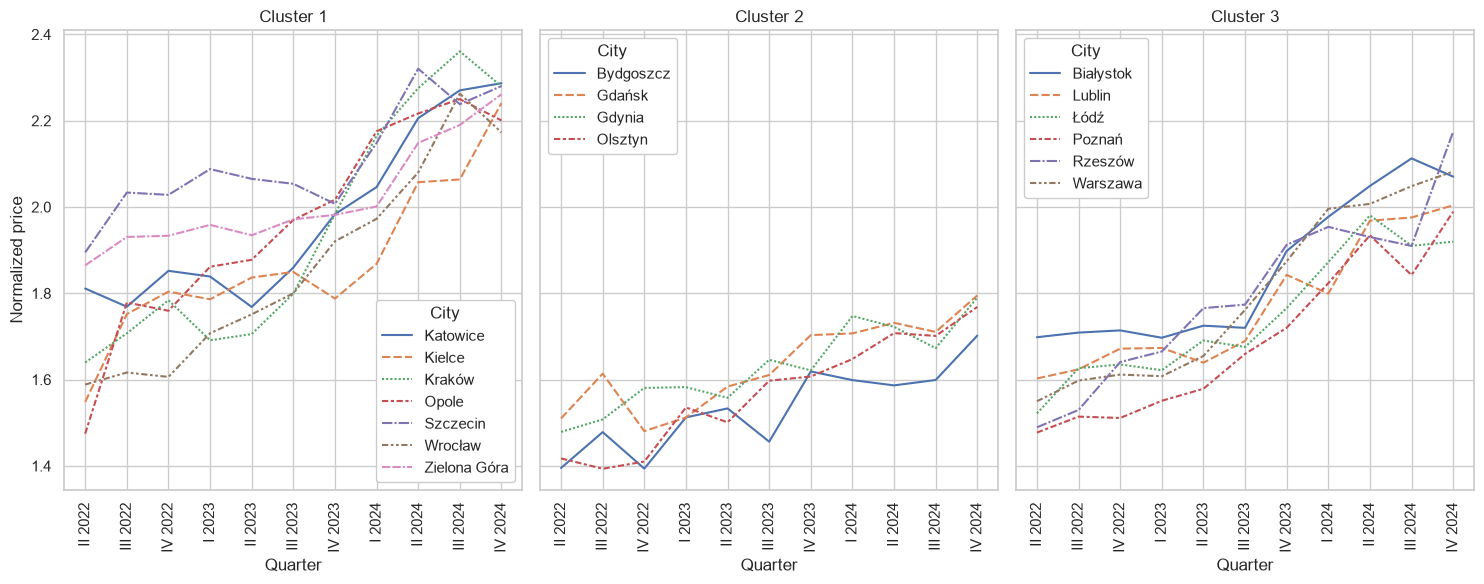

In [23]:
model4 = TimeSeriesKMeans(n_clusters=3, metric="dtw", max_iter=300, random_state=42)
labels4 = model4.fit_predict(X)


fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharey=True)

for cluster in range(3):
    cluster_cities = [pierwotny_slice_wojna_koniec_df_n.columns[i] for i in range(len(labels4)) if labels4[i] == cluster]
    
    sns.lineplot(data=pierwotny_slice_wojna_koniec_df_n[cluster_cities], ax=axes[cluster])
    
    axes[cluster].set_title(f'Cluster {cluster + 1}')
    axes[cluster].set_xlabel("Quarter")
    axes[cluster].set_ylabel("Normalized price")
    axes[cluster].tick_params(axis='x', rotation=90)
    
    if cluster == 0:
        leg = axes[cluster].legend(title="City", loc='lower right')
    else:
        leg = axes[cluster].legend(title="City", loc='upper left')
    leg.get_frame().set_facecolor('white')
    leg.get_frame().set_alpha(1)
    

plt.tight_layout()
plt.show()

## Breakpoint Detection (PELT)

### Average Across All Cities

In [24]:
series = pierwotny_slice_df_n.mean(axis=1).values
algo   = rpt.Pelt(model="rbf").fit(series)
bkpt   = algo.predict(pen=3)[-2]
display(pierwotny_slice_df_n.index[bkpt])

'IV 2021'

In [25]:
series = pierwotny_slice_df_n.mean(axis=1).values
algo   = rpt.Pelt(model="rbf", min_size=4).fit(series)

# policz wiele cięć (penalty odpowiednio małe)
bkps_all = algo.predict(pen=2)          # lista, ostatni element = len(series)
bkps_sorted = sorted(bkps_all[:-1])     # usuń koniec serii

# weź dokładnie dwa najwcześniejsze
if len(bkps_sorted) < 2:
    raise ValueError("Znaleziono mniej niż 2 breakpointy – zwiększ pen lub min_size")
b1, b2 = bkps_sorted[:2]

display(pierwotny_slice_df_n.index[[b1-1, b2-1]])

Index(['III 2021', 'IV 2022'], dtype='str', name='Kwartał')

In [26]:
series = pierwotny_slice_df_n.mean(axis=1).values
algo   = rpt.Pelt(model="rbf", min_size=2).fit(series)

bkps_all = algo.predict(pen=1)           # zwróci ≥3 cięć dzięki małej karze
bkps_sorted = sorted(bkps_all[:-1])      # usuń koniec serii i posortuj

if len(bkps_sorted) < 3:
    raise ValueError("Znaleziono < 3 breakpointy – zmniejsz pen lub min_size")

b1, b2, b3 = bkps_sorted[:3]             # trzy najwcześniejsze
display(pierwotny_slice_df_n.index[[b1-1, b2-1, b3-1]])

Index(['I 2019', 'III 2021', 'IV 2022'], dtype='str', name='Kwartał')

/var/folders/tx/9g_s4rm56clg1s64hp55l8tw0000gn/T/ipykernel_30535/2588969980.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="City", ncol=2, loc='upper left')


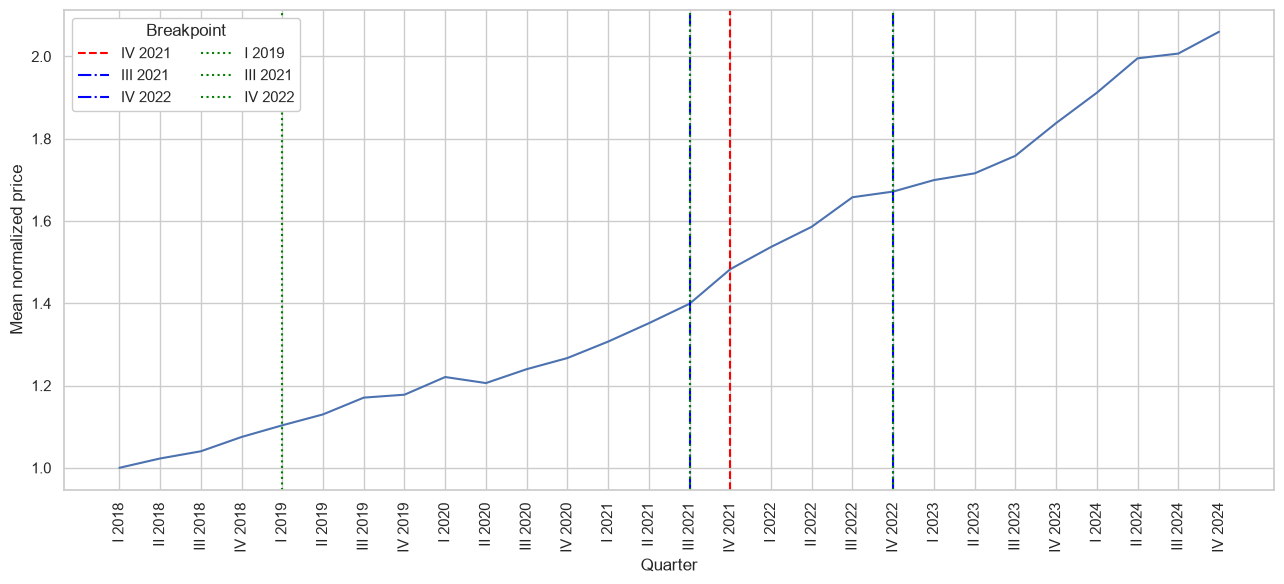

In [27]:
pd_series = pd.Series(series, index=pierwotny_slice_df_n.index)

plt.figure(figsize=(13, 6))
sns.lineplot(data=pd_series)

plt.legend(title="City", ncol=2, loc='upper left')
#plt.title("Barycenter of the full series")
plt.xlabel("Quarter")
plt.ylabel("Mean normalized price")
plt.xticks(rotation=90)

x_pos_IV2021= pierwotny_slice_df_n.index.get_loc("IV 2021")
plt.axvline(x=x_pos_IV2021, color='red', linestyle='--', label="IV 2021")

x_pos_III2021= pierwotny_slice_df_n.index.get_loc("III 2021")
plt.axvline(x=x_pos_III2021, color='blue', linestyle='-.', label="III 2021")
x_pos_IV2022= pierwotny_slice_df_n.index.get_loc("IV 2022")
plt.axvline(x=x_pos_IV2022, color='blue', linestyle='-.', label="IV 2022")

x_pos_I2019= pierwotny_slice_df_n.index.get_loc("I 2019")
plt.axvline(x=x_pos_I2019, color='green', linestyle=':', label="I 2019")
x_pos_III2021= pierwotny_slice_df_n.index.get_loc("III 2021")
plt.axvline(x=x_pos_III2021, color='green', linestyle=':', label="III 2021")
x_pos_IV2022= pierwotny_slice_df_n.index.get_loc("IV 2022")
plt.axvline(x=x_pos_IV2022, color='green', linestyle=':', label="IV 2022")


legend = plt.legend(title="Breakpoint", ncol=2, loc='upper left')
frame = legend.get_frame()
frame.set_alpha(1) 


plt.tight_layout()
plt.show()

# Summary Visualisations

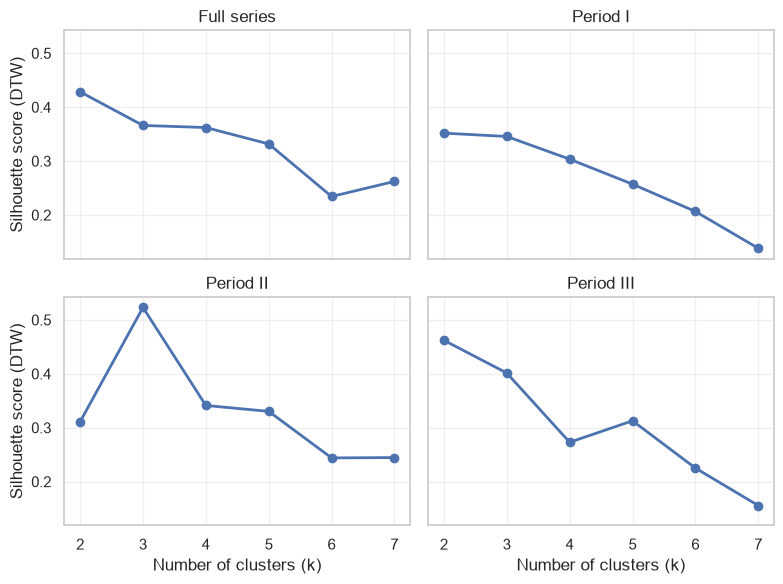

In [28]:
k_range   = range(2, 8)
all_sils  = [sils, sils1, sils2, sils3]
titles    = ["Full series", "Period I", "Period II", "Period III"]


fig, axes = plt.subplots(2, 2, figsize=(8, 6), sharex=True, sharey=True)


axes = axes.flatten()

for i, (ax, sil, title) in enumerate(zip(axes, all_sils, titles)):
    ax.plot(k_range, sil, marker="o", linewidth=2)
    ax.set_title(title, fontsize=12)
    ax.set_xticks(list(k_range))
    ax.grid(alpha=0.3)
    if i >= 2:
        ax.set_xlabel("Number of clusters (k)")
    if i % 2 == 0:
        ax.set_ylabel("Silhouette score (DTW)")
        
plt.tight_layout()
plt.show()